In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV


In [3]:
from google.colab import files
uploaded = files.upload()

Saving WineQT.csv to WineQT (1).csv


In [5]:
df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [8]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


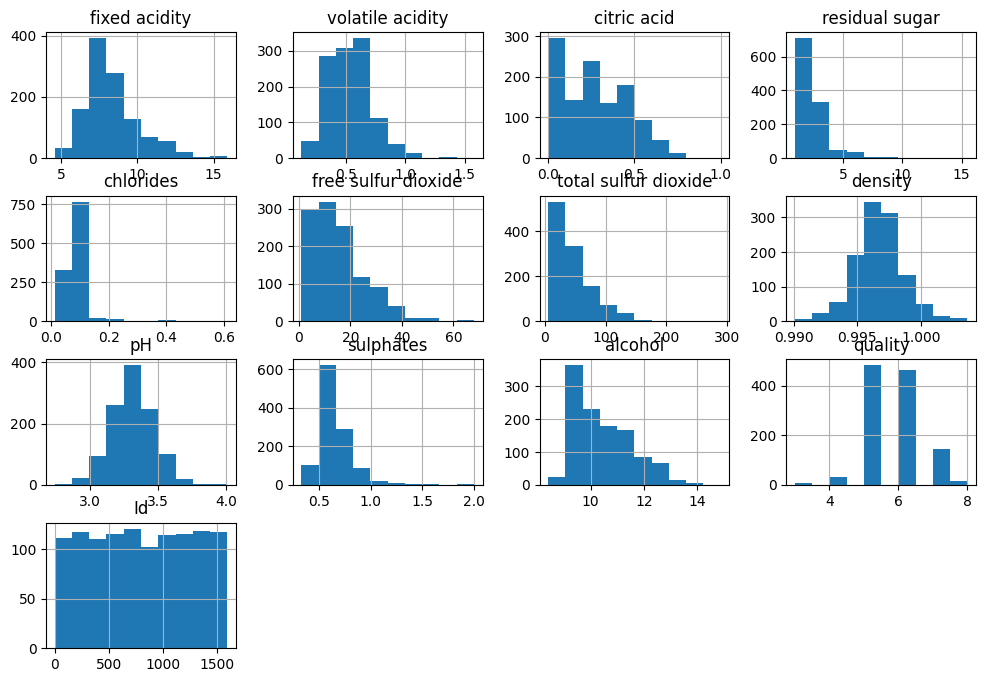

In [9]:
df.hist(figsize=(12,8))
plt.show()

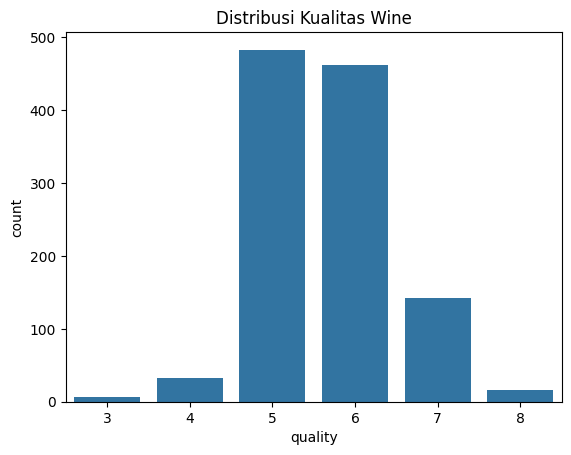

In [10]:
sns.countplot(x="quality", data=df)
plt.title("Distribusi Kualitas Wine")
plt.show()

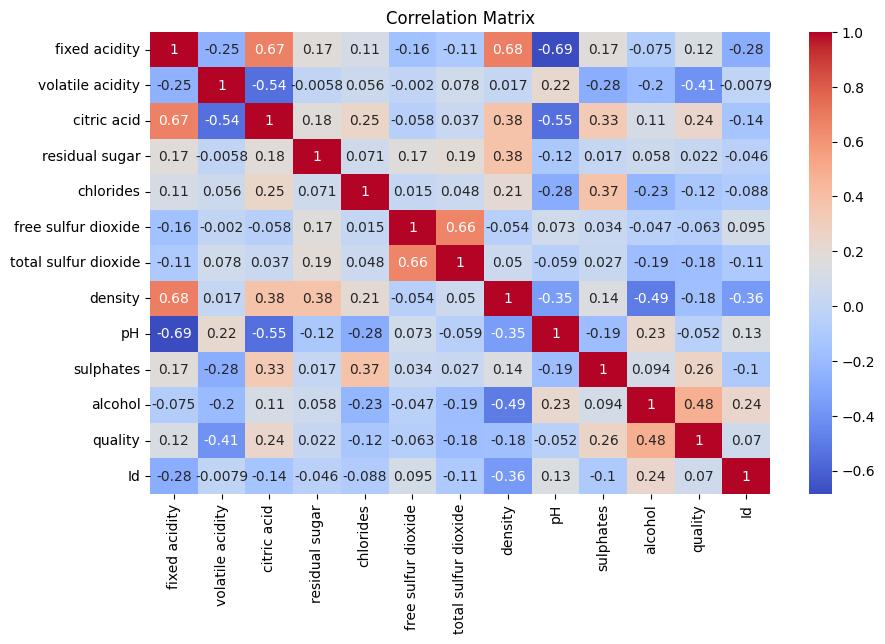

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [12]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

In [13]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [18]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy Logistic Regression:", accuracy_score(y_test, pred_lr))

Accuracy Logistic Regression: 0.9008746355685131


In [19]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("Accuracy KNN:", accuracy_score(y_test, pred_knn))

Accuracy KNN: 0.8688046647230321


In [20]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, pred_rf))

Accuracy Random Forest: 0.9037900874635568


In [24]:
best_knn = grid_knn.best_estimator_

pred_knn = best_knn.predict(X_test)

print("Accuracy KNN after tuning:", accuracy_score(y_test, pred_knn))

Accuracy KNN after tuning: 0.8717201166180758


In [23]:
best_rf = grid_rf.best_estimator_

pred_rf = best_rf.predict(X_test)

print("Accuracy RF after tuning:", accuracy_score(y_test, pred_rf))

Accuracy RF after tuning: 0.892128279883382


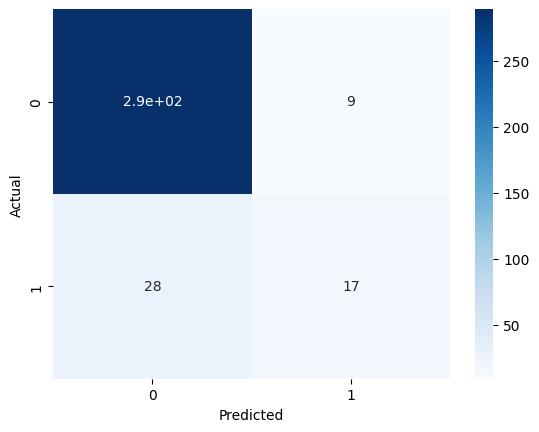

In [25]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       298
           1       0.65      0.38      0.48        45

    accuracy                           0.89       343
   macro avg       0.78      0.67      0.71       343
weighted avg       0.88      0.89      0.88       343



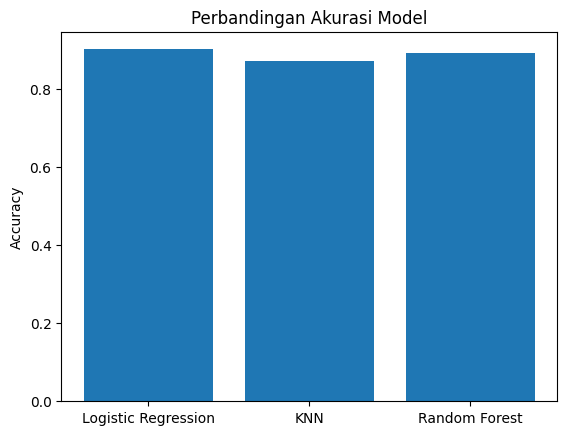

In [27]:
models = ["Logistic Regression","KNN","Random Forest"]

accuracy = [
accuracy_score(y_test, pred_lr),
accuracy_score(y_test, pred_knn),
accuracy_score(y_test, pred_rf)
]

plt.bar(models, accuracy)

plt.title("Perbandingan Akurasi Model")

plt.ylabel("Accuracy")

plt.show()